In [ ]:
import os
os.listdir("/content")


['.config',
 'Aadhaar Demographic Update dataset.csv',
 'Aadhaar Biometric Update dataset.csv',
 'Aadhaar Enrolment dataset.csv',
 'sample_data']

In [ ]:
import pandas as pd

enrol_df = pd.read_csv("/content/Aadhaar Enrolment dataset.csv")
demo_df  = pd.read_csv("/content/Aadhaar Demographic Update dataset.csv")
bio_df   = pd.read_csv("/content/Aadhaar Biometric Update dataset.csv")

enrol_df.head()


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,01-06-2025,Telangana,Hyderabad,500028,295,178,11
1,01-07-2025,Telangana,Hyderabad,500013,492,126,11
2,01-07-2025,Telangana,Hyderabad,500001,253,132,23
3,01-07-2025,Telangana,Hyderabad,500029,98,51,14
4,01-07-2025,Telangana,Hyderabad,500032,92,53,20


In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
enrol_df = pd.read_csv("/content/Aadhaar Enrolment dataset.csv")
demo_df  = pd.read_csv("/content/Aadhaar Demographic Update dataset.csv")
bio_df   = pd.read_csv("/content/Aadhaar Biometric Update dataset.csv")

print("Enrolment:", enrol_df.shape)
print("Demographic:", demo_df.shape)
print("Biometric:", bio_df.shape)


Enrolment: (51480, 7)
Demographic: (105672, 6)
Biometric: (240694, 6)


In [ ]:
enrol_df.head()


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,01-06-2025,Telangana,Hyderabad,500028,295,178,11
1,01-07-2025,Telangana,Hyderabad,500013,492,126,11
2,01-07-2025,Telangana,Hyderabad,500001,253,132,23
3,01-07-2025,Telangana,Hyderabad,500029,98,51,14
4,01-07-2025,Telangana,Hyderabad,500032,92,53,20


In [ ]:
demo_df.head()


,date,state,district,pincode,demo_age_5_17,demo_age_17_
0,16-10-2025,Telangana,Adilabad,504102,0,1
1,16-10-2025,Telangana,Adilabad,504106,0,7
2,16-10-2025,Telangana,Adilabad,504214,2,1
3,16-10-2025,Telangana,Adilabad,504216,1,7
4,16-10-2025,Telangana,Adilabad,504251,1,4


In [ ]:
bio_df.head()


,date,state,district,pincode,bio_age_5_17,bio_age_17_
0,25-11-2025,Telangana,Mancherial,504220,0,1
1,25-11-2025,Telangana,Rangareddy,500068,1,0
2,25-11-2025,Telangana,Warangal Rural,506319,1,0
3,18-12-2025,Telangana,Nagarkurnool,509326,0,1
4,19-11-2025,Telangana,Khammam,507116,1,0


In [ ]:
# Rename columns for consistency (adjust if column names differ)
enrol_df.columns = enrol_df.columns.str.lower().str.strip()
demo_df.columns  = demo_df.columns.str.lower().str.strip()
bio_df.columns   = bio_df.columns.str.lower().str.strip()


In [ ]:
demo_risk = demo_df.groupby(['state', 'district'])['total_updates'].sum().reset_index()
bio_risk  = bio_df.groupby(['state', 'district'])['total_updates'].sum().reset_index()

demo_risk.rename(columns={'total_updates': 'demo_updates'}, inplace=True)
bio_risk.rename(columns={'total_updates': 'bio_updates'}, inplace=True)


KeyError: 'Column not found: total_updates'

In [ ]:
print(demo_df.columns)


Index(['date', 'state', 'district', 'pincode', 'demo_age_5_17',
       'demo_age_17_'],
      dtype='object')


In [ ]:
print(bio_df.columns)


Index(['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_'], dtype='object')


In [ ]:
bio_df['total_bio_updates'] = (
    bio_df['bio_age_5_17'] + bio_df['bio_age_17_']
)


In [ ]:
bio_risk = (
    bio_df
    .groupby(['state', 'district'])['total_bio_updates']
    .sum()
    .reset_index()
)

bio_risk.head()


,state,district,total_bio_updates
0,Telangana,Adilabad,117396
1,Telangana,Bhadradri Kothagudem,36555
2,Telangana,Hanumakonda,21778
3,Telangana,Hyderabad,318017
4,Telangana,Jagitial,18484


In [ ]:
print(demo_df.columns)


Index(['date', 'state', 'district', 'pincode', 'demo_age_5_17',
       'demo_age_17_'],
      dtype='object')


In [ ]:
demo_df['total_demo_updates'] = (
    demo_df['demo_age_5_17'] + demo_df['demo_age_17_']
)


In [ ]:
demo_risk = (
    demo_df
    .groupby(['state', 'district'])['total_demo_updates']
    .sum()
    .reset_index()
)

demo_risk.head()


,state,district,total_demo_updates
0,Telangana,Adilabad,43303
1,Telangana,Bhadradri Kothagudem,37650
2,Telangana,Hanumakonda,23639
3,Telangana,Hyderabad,220809
4,Telangana,Jagitial,19597


In [ ]:
print(enrol_df.columns)


Index(['date', 'state', 'district', 'pincode', 'age_0_5', 'age_5_17',
       'age_18_greater'],
      dtype='object')


In [ ]:
risk_df = enrol_df.merge(demo_risk, on=['state', 'district'], how='left')
risk_df = risk_df.merge(bio_risk, on=['state', 'district'], how='left')

risk_df.fillna(0, inplace=True)


In [ ]:
risk_df['duplicate_risk_score'] = (
    0.6 * risk_df['total_demo_updates'] +
    0.4 * risk_df['total_bio_updates']
)


In [ ]:
risk_df.sort_values(
    by='duplicate_risk_score',
    ascending=False
).head(10)


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,total_demo_updates,total_bio_updates,duplicate_risk_score
9112,11-06-2025,Telangana,K.v. Rangareddy,509327,1,0,0,201494.0,352475.0,261886.4
9113,11-06-2025,Telangana,K.v. Rangareddy,509371,0,1,0,201494.0,352475.0,261886.4
9114,11-06-2025,Telangana,K.v. Rangareddy,509410,2,1,0,201494.0,352475.0,261886.4
9305,12-06-2025,Telangana,K.v. Rangareddy,500035,3,0,0,201494.0,352475.0,261886.4
9306,12-06-2025,Telangana,K.v. Rangareddy,500046,2,1,0,201494.0,352475.0,261886.4
9307,12-06-2025,Telangana,K.v. Rangareddy,500047,2,2,0,201494.0,352475.0,261886.4
9308,12-06-2025,Telangana,K.v. Rangareddy,500070,3,1,0,201494.0,352475.0,261886.4
9309,12-06-2025,Telangana,K.v. Rangareddy,500081,1,0,0,201494.0,352475.0,261886.4
40,03-09-2025,Telangana,K.v. Rangareddy,500083,1,0,0,201494.0,352475.0,261886.4
41,03-09-2025,Telangana,K.v. Rangareddy,500084,0,1,0,201494.0,352475.0,261886.4


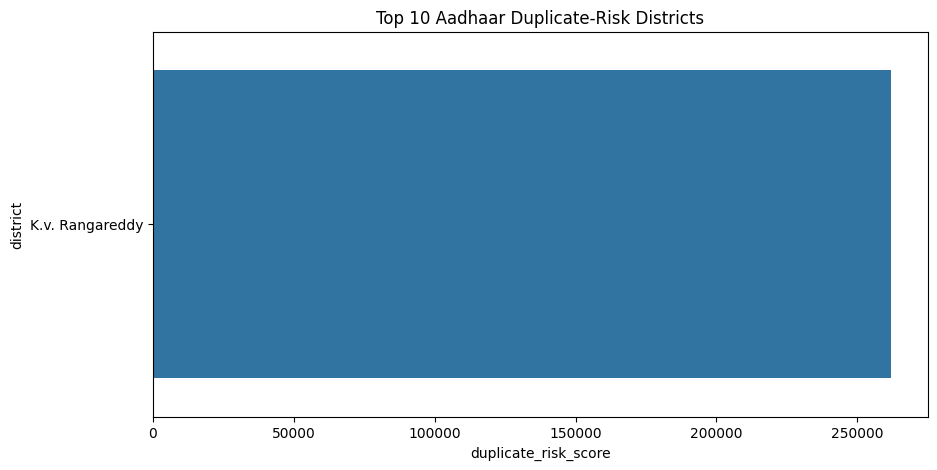

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_risk = risk_df.sort_values(
    by='duplicate_risk_score',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x='duplicate_risk_score',
    y='district',
    data=top_risk
)
plt.title("Top 10 Aadhaar Duplicate-Risk Districts")
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest


In [ ]:
features = risk_df[
    ['total_demo_updates', 'total_bio_updates', 'duplicate_risk_score']
]


In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


In [ ]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,  # top 5% anomalies
    random_state=42
)

risk_df['anomaly_flag'] = iso_forest.fit_predict(scaled_features)


In [ ]:
anomalies = risk_df[risk_df['anomaly_flag'] == -1]

anomalies[['state', 'district', 'duplicate_risk_score']].head(10)


,state,district,duplicate_risk_score
31,Telangana,Jangaon,1223.8
106,Telangana,Medchal-malkajgiri,84279.6
107,Telangana,Medchal-malkajgiri,84279.6
108,Telangana,Medchal-malkajgiri,84279.6
109,Telangana,Medchal−malkajgiri,5610.0
134,Telangana,Rangareddy,6469.2
189,Telangana,Jangaon,1223.8
253,Telangana,Medchal-malkajgiri,84279.6
254,Telangana,Medchal-malkajgiri,84279.6
255,Telangana,Medchal-malkajgiri,84279.6


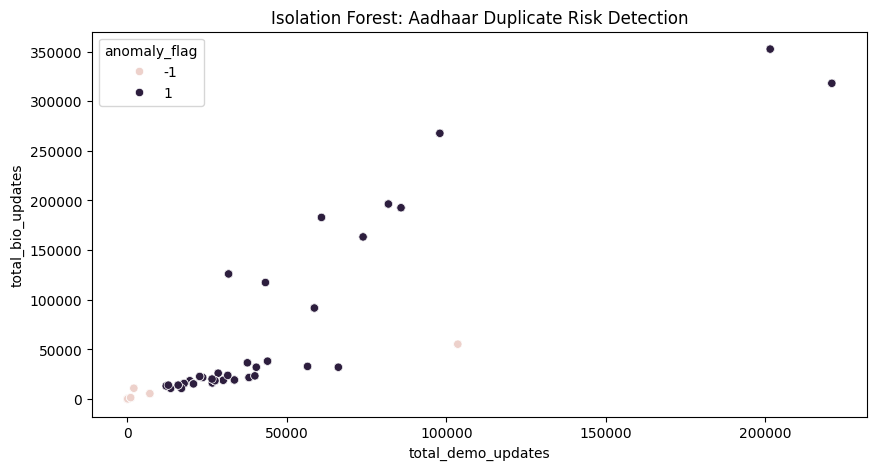

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    data=risk_df,
    x='total_demo_updates',
    y='total_bio_updates',
    hue='anomaly_flag'
)
plt.title("Isolation Forest: Aadhaar Duplicate Risk Detection")
plt.show()


In [ ]:
import hashlib


In [ ]:
def generate_did(state, district):
    raw = f"{state}_{district}"
    return hashlib.sha256(raw.encode()).hexdigest()


In [ ]:
risk_df['district_did'] = risk_df.apply(
    lambda x: generate_did(x['state'], x['district']),
    axis=1
)


In [ ]:
blockchain_ledger = risk_df[
    ['district_did', 'total_demo_updates', 'total_bio_updates', 'anomaly_flag']
]


In [ ]:
blockchain_ledger.head()


,district_did,total_demo_updates,total_bio_updates,anomaly_flag
0,b848c199d4097f67cc929a1a0862b9da8e4092dc9496a8...,220809.0,318017.0,1
1,b848c199d4097f67cc929a1a0862b9da8e4092dc9496a8...,220809.0,318017.0,1
2,b848c199d4097f67cc929a1a0862b9da8e4092dc9496a8...,220809.0,318017.0,1
3,b848c199d4097f67cc929a1a0862b9da8e4092dc9496a8...,220809.0,318017.0,1
4,b848c199d4097f67cc929a1a0862b9da8e4092dc9496a8...,220809.0,318017.0,1


In [ ]:
def verify_high_risk(anomaly_flag):
    return anomaly_flag == -1


In [ ]:
risk_df['zkp_high_risk_proof'] = risk_df['anomaly_flag'].apply(verify_high_risk)


In [ ]:
import os
os.listdir()


['.config',
 'Aadhaar Demographic Update dataset.csv',
 'Aadhaar Biometric Update dataset.csv',
 'Aadhaar Enrolment dataset.csv',
 'sample_data']

In [ ]:
import pandas as pd

enroll_df = pd.read_csv("Aadhaar Enrolment dataset.csv")
demo_df   = pd.read_csv("Aadhaar Demographic Update dataset.csv")
bio_df    = pd.read_csv("Aadhaar Biometric Update dataset.csv")

print(enroll_df.columns)
print(demo_df.columns)
print(bio_df.columns)


Index(['date', 'state', 'district', 'pincode', 'age_0_5', 'age_5_17',
       'age_18_greater'],
      dtype='object')
Index(['date', 'state', 'district', 'pincode', 'demo_age_5_17',
       'demo_age_17_'],
      dtype='object')
Index(['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_'], dtype='object')


In [ ]:
demo_df["demo_updates"] = demo_df["demo_age_5_17"] + demo_df["demo_age_17_"]
bio_df["bio_updates"]   = bio_df["bio_age_5_17"]  + bio_df["bio_age_17_"]


In [ ]:
demo_risk = demo_df.groupby(["state", "district"])["demo_updates"].sum().reset_index()
bio_risk  = bio_df.groupby(["state", "district"])["bio_updates"].sum().reset_index()

enroll_risk = enroll_df.groupby(["state", "district"]).size().reset_index(name="enrollments")


In [ ]:
risk_df = enroll_risk.merge(demo_risk, on=["state", "district"], how="left")
risk_df = risk_df.merge(bio_risk, on=["state", "district"], how="left")

risk_df.fillna(0, inplace=True)


In [ ]:
risk_df["risk_score"] = (
    0.4 * risk_df["enrollments"] +
    0.35 * risk_df["demo_updates"] +
    0.25 * risk_df["bio_updates"]
)

risk_df["risk_level"] = pd.cut(
    risk_df["risk_score"],
    bins=[-1, 1000, 5000, float("inf")],
    labels=["Low", "Medium", "High"]
)


In [ ]:
risk_df.to_csv("enhanced_uidai_risk_registry.csv", index=False)


In [ ]:
risk_df.head()


,state,district,enrollments,demo_updates,bio_updates,risk_score,risk_level
0,Telangana,Adilabad,1563,43303.0,117396.0,45130.25,High
1,Telangana,Bhadradri Kothagudem,1060,37650.0,36555.0,22740.25,High
2,Telangana,Hanumakonda,781,23639.0,21778.0,14030.55,High
3,Telangana,Hyderabad,3721,220809.0,318017.0,158275.80,High
4,Telangana,Jagitial,967,19597.0,18484.0,11866.75,High


In [ ]:
from google.colab import files
files.download("enhanced_uidai_risk_registry.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>